# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/ANALYTICS/Colaboratory/data/yulu_rental.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [6]:
season_mapping = {
    12:1, 1:1, 2:1,
    3:2, 4:2, 5:2,
    6:3, 7:3, 8:3, 9:3,
    10:4, 11:4
}

df['weather_season_india'] = df['month'].map(season_mapping)

#AІ дещо підказав, як це правильно реалізувати

In [7]:
df[['month', 'weather_season_india']].tail(10)

,month,weather_season_india
datetime,,
2012-12-19 14:00:00,12,1
2012-12-19 15:00:00,12,1
2012-12-19 16:00:00,12,1
2012-12-19 17:00:00,12,1
2012-12-19 18:00:00,12,1
2012-12-19 19:00:00,12,1
2012-12-19 20:00:00,12,1
2012-12-19 21:00:00,12,1
2012-12-19 22:00:00,12,1


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   season                10886 non-null  int64  
 1   holiday               10886 non-null  int64  
 2   workingday            10886 non-null  int64  
 3   weather               10886 non-null  int64  
 4   temp                  10886 non-null  float64
 5   atemp                 10886 non-null  float64
 6   humidity              10886 non-null  int64  
 7   windspeed             10886 non-null  float64
 8   casual                10886 non-null  int64  
 9   registered            10886 non-null  int64  
 10  count                 10886 non-null  int64  
 11  date                  10886 non-null  object 
 12  day                   10886 non-null  int32  
 13  week                  10886 non-null  UInt32 
 14  weekday_num           10886 non-nul

У нас 10886 рядків та 20 колонок

У одному рядку міститься інформація погодинно. Загалом усі дані за період із 2011-01-01 до 2012-12-19

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [9]:
count_by_days = df['count'].resample('D').sum()   #Ai пояснив, що треба через resample

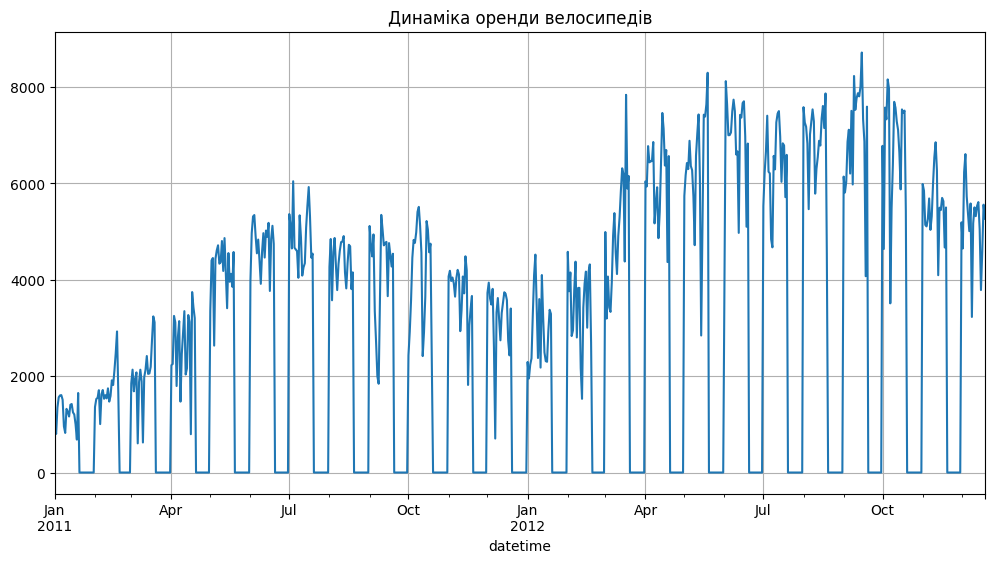

In [10]:
count_by_days.plot(
    figsize = (12,6),
    title = 'Динаміка оренди велосипедів',
    grid = True
);

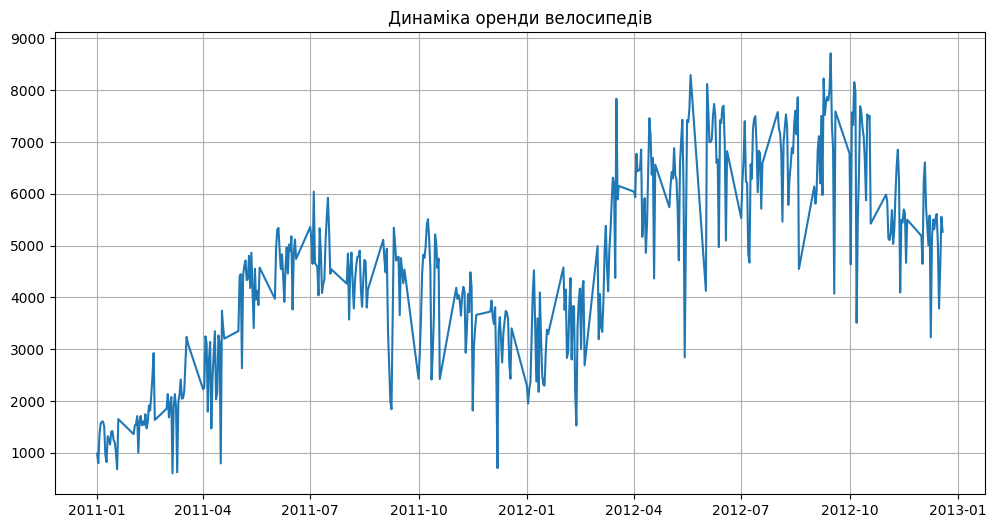

In [11]:
df.groupby(df.index.date)['count'].sum().plot(
    figsize = (12,6),
    title = 'Динаміка оренди велосипедів',
    grid = True
);

1) Заломи могли бути спричинені відсутністю даних за інші дні
Прибрати можна групуванням(другий графік).

2) Загальна тенденція йде до зростання.

3) Чітко видні просідання графіку в холодну пору року, як і зріст в теплу.

4) Є періоди із аномально високим значенням. Для прикладу - 2012-06, 2012-09.
Аномально низькі - 2011-03, 2011-12. Це все пояснюється погодними умовами.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [12]:
season_names = {1: 'Winter', 2: 'Summer', 3: 'Monsoon', 4: 'Post-monsoon'}
mean_by_seasons = df.groupby('weather_season_india')['count'].mean()
mean_by_seasons.index = mean_by_seasons.index.map(season_names)
# AI підкзав за map щоб змінити назви

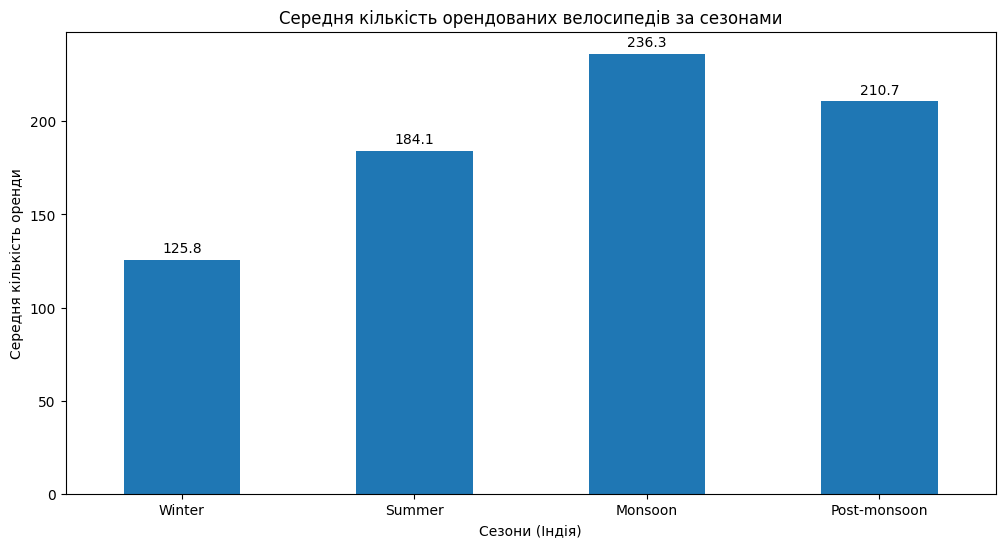

In [13]:
ax = mean_by_seasons.plot.bar(
    figsize = (12,6),
    title="Середня кількість орендованих велосипедів за сезонами",
    xlabel="Сезони (Індія)",
    ylabel="Середня кількість оренди",
    rot=0
)

ax.bar_label(ax.containers[0], fmt='%.1f', padding=3); #AI підказав як це зробити

1) У третій квартал (сезон Monsoon) найбільша середня кількість оренди.

2) Це пов'язано із погодніми умовами в ці сезони.
(АІ детальніше розповів мені за цей сезон)
В Індії зима (Winter) є порівняно прохолодною, а літо (Summer) — екстремально спекотним (температура часто перевищує +40°C), що заважає комфортним поїздкам. Сезон мусонів (Monsoon), попри дощі, приносить довгоочікуване зниження температури, а хмарність робить перебування на вулиці приємнішим, що стимулює попит.

3) 236,3 (Monsoon) / 125,8(Winter) = 1.88

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [14]:
mean_by_month = df.groupby('month')['count'].mean()

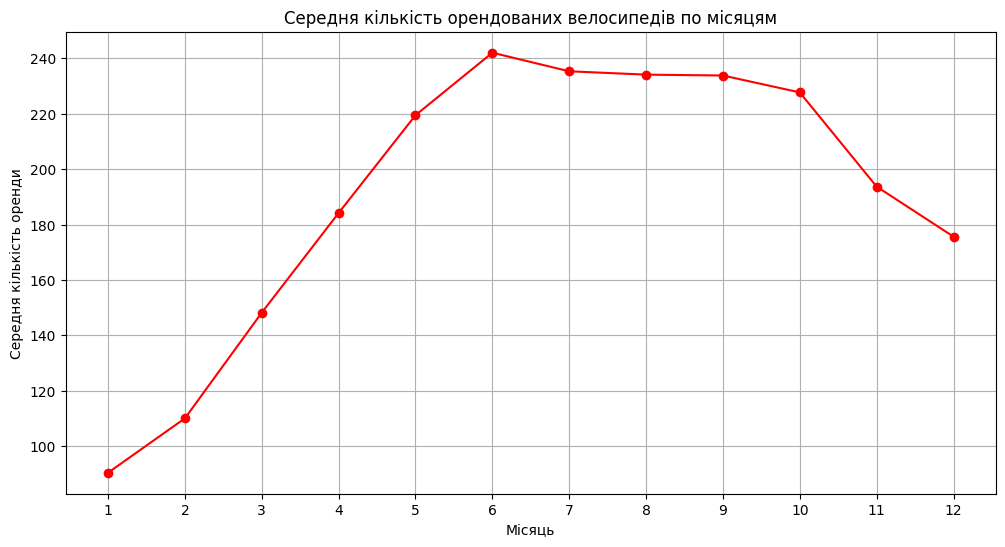

In [15]:
mean_by_month.plot(
    figsize = (12,6),
    marker = 'o',
    xlabel = 'Місяць',
    ylabel = 'Середня кількість оренди',
    title = 'Середня кількість орендованих велосипедів по місяцям',
    grid = True,
    color = 'red',
    xticks=range(1, 13)  # AI підказав, як зробити чітко 12 поділок
);

1) Пік у шостому місяці, а спад у першому.

2) Так, збігається із попереднім завданням.

3) У зв'язку із холодною погодою зимою кількість оренд стрімко падає. Навесні із потеплінням зростає і кількість бажаючих. Так як літній період часу попри спеку має дощі, то це найкомфортніший проміжок часу для їзди. У зв'язку із цим маємо пікові значення оренди. З приходом осені температура спадає - так само знижується рівень оренди.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

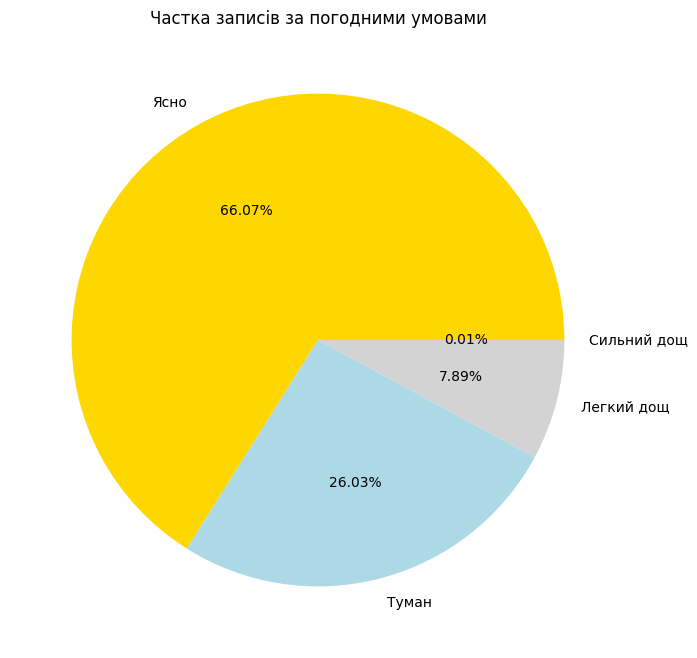

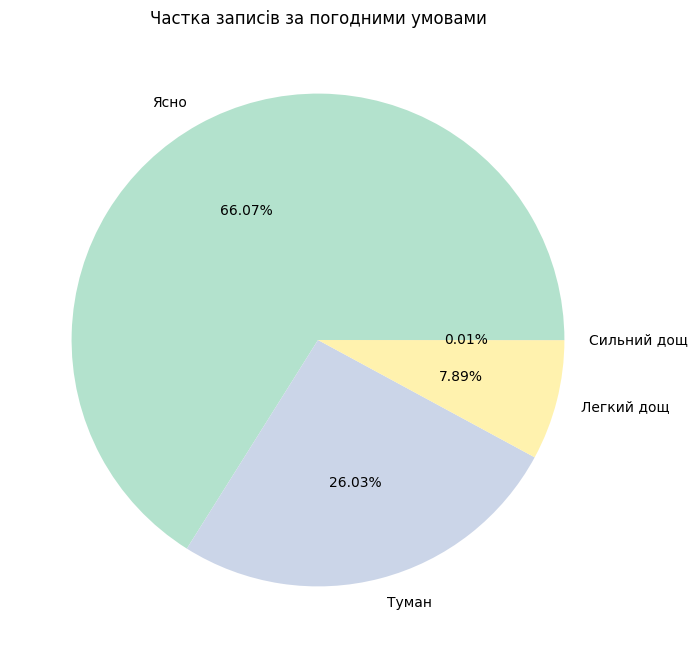

In [16]:
weather_counting = df['weather'].value_counts().plot.pie(
    figsize = (8,8),
    autopct ='%1.2f%%',    #AI підказав, як посунути відсоток
    labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title = 'Частка записів за погодними умовами',
    ylabel = '',
    colormap = 'Pastel2'
)

1) Переважає ясна погода.

2) Днів із сильним дощем практично немає - лише 0,01%.

3) Ясна та туманна погода сумарно становлять понад 92% від усіх записів у наборі даних. Це дає чітко зрозуміти, що збір даних відбувався переважно за умов, які є сприятливими для користувачів велопрокату.


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [17]:
weather_names = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}

In [18]:
df['weather_text'] = df['weather'].map(weather_names) # не хотіло ставити у налаштування графіку, АІ сказав, що треба окремо винести

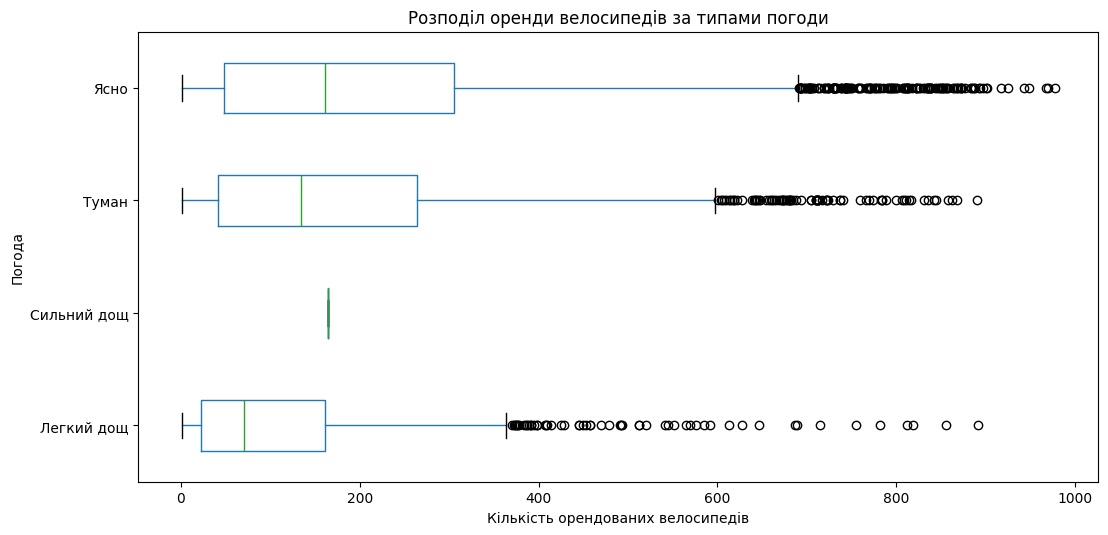

In [19]:
df.boxplot(
    column = 'count',
    by = 'weather_text',
    vert = False,  # AI підказав за це
    figsize = (12,6),
    grid = False
)

plt.title ('Розподіл оренди велосипедів за типами погоди')
plt.suptitle('')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Погода');

1) Найбільший розкид при ясній погоді.

2) Викиди зустрічаються при всій погоді, окрім сильного дощу.

3) Медіанне значення найвище при ясній погоді, хоч і візуально здається, що при сильному дощі. Це спричинено малою кількістю таких показників.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

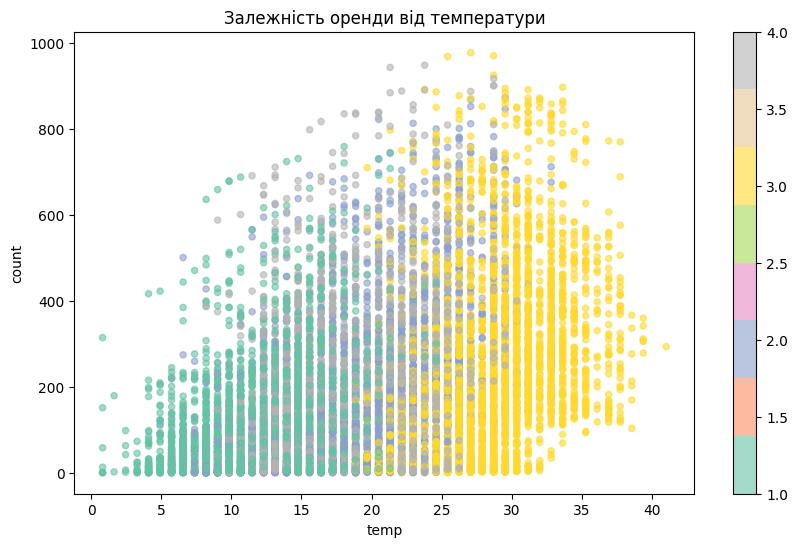

In [20]:
cor_temp_count = df.plot.scatter(
    x = 'temp',
    y = 'count',
    c=df['weather_season_india'].values.astype(float), # був баг і не хотіло працювати - довго возився із АІ і вийшло якось так
    colormap = 'Set2',
    title = 'Залежність оренди від температури',
    figsize = (10,6),
    alpha = 0.6
);


Зв'язок присутній і він позитивний. Видно, що зі збільшенням температури росте і кількість орендованих велосипедів. Проте після 30-35 градусів видно спад, адже кататись стає дуже жарко.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [36]:
diff_users = df.groupby('weekday')[['casual', 'registered']].mean()

In [44]:
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

diff_users = diff_users.reindex(ordered_days)   # дивився, як було в лекції - не вийшло, АІ підказав так

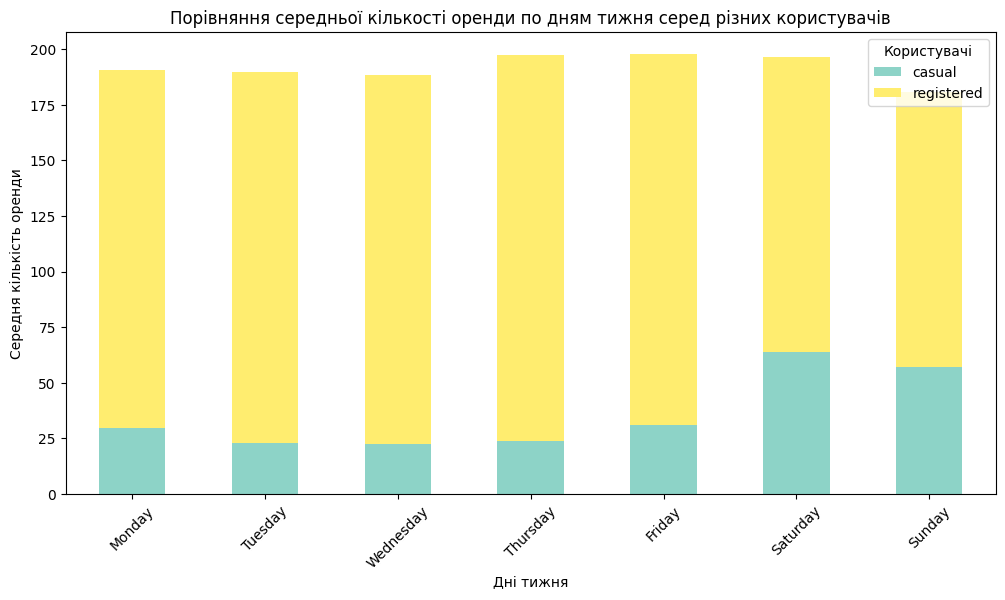

In [60]:
diff_users.plot.bar(
    figsize = (12, 6),
    stacked = True,
    rot = 45,
    title = 'Порівняння середньої кількості оренди по дням тижня серед різних користувачів',
    xlabel = 'Дні тижня',
    ylabel = 'Середня кількість оренди',
    colormap = 'Set3',

)

plt.legend(title = 'Користувачі');

1) Більше оренд від зареєстрованих користувачів у будні дні.

2) Поведінку можна пояснити, як спосіб добирання до роботи або важливих місць в робочі дні. У вихідні дні збільшується кількість і випадкових користувачів, адже це може бути як прогулянку або дозвілля.